## Q5 V-Plot

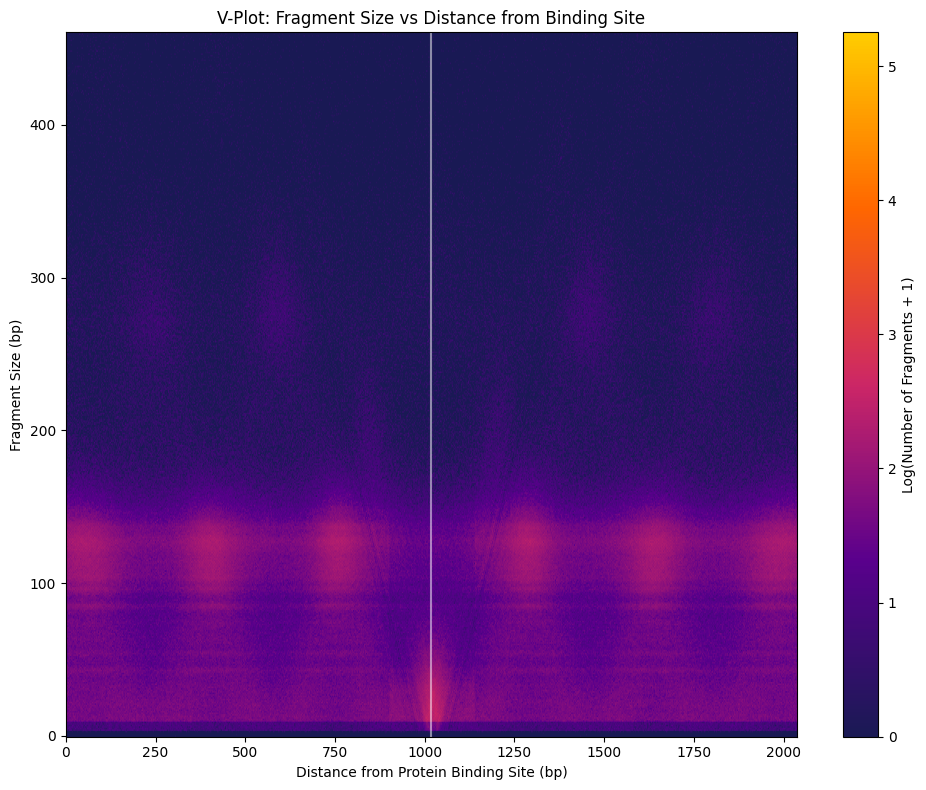

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Columns 2 & 3 for the protein binding site, 8 & 9 for the DNA fragment coordinates.
dna_data = pd.read_csv('mapped.bed', sep='\t', usecols=[2, 3, 8, 9], header=None)

# We'll use these to figure out how far fragments are from their associated binding sites.
dna_data['prot_center'] = (dna_data[2] + dna_data[3]) / 2
dna_data['frag_center'] = (dna_data[8] + dna_data[9]) / 2

# This will be the x-axis in our V-plot.
dna_data['pos_diff'] = dna_data['frag_center'] - dna_data['prot_center']

# Calculate fragment sizes (i.e., their lengths). This will go on the y-axis.
dna_data['frag_size'] = dna_data[9] - dna_data[8]

# count how many times that combo appears in the data.
count_matrix = dna_data.groupby(['frag_size', 'pos_diff']).size().reset_index(name='fragment_count')

# Rows = fragment sizes, Columns = relative positions, Values = fragment counts.
vplot_matrix = count_matrix.pivot(index='frag_size', columns='pos_diff', values='fragment_count').fillna(0)

# Set up the plot.
plt.figure(figsize=(10, 8))

# Define a custom colormap — starts from deep blue and moves through purple, red, and orange to yellow.
colors = [
    (0.1, 0.1, 0.33),
    (0.35, 0.0, 0.55),  
    (0.8, 0.15, 0.4),
    (1.0, 0.4, 0.0),
    (1.0, 0.8, 0.0)
]
cmap_name = 'dna_binding_vplot'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=256)
vplot_data = np.log1p(vplot_matrix)

# Plot the heatmap using our custom colormap.
img = plt.imshow(
    vplot_data,
    aspect='auto',
    origin='lower',  
    cmap=cm
)

plt.xlabel('Distance from Protein Binding Site (bp)')
plt.ylabel('Fragment Size (bp)')
plt.title('V-Plot: Fragment Size vs Distance from Binding Site')
plt.colorbar(img, label='Log(Number of Fragments + 1)')

plt.grid(False)

# Mark the binding site position with a dashed vertical line for reference.
# As 0 isn’t in the data, we drew the line in the middle.
if 0 in vplot_data.columns:
    center_x = vplot_data.columns.get_loc(0)
else:
    center_x = len(vplot_data.columns) // 2
plt.axvline(x=center_x, color='white', alpha=0.5)

# Adjust layout so labels and title don’t get cut off.
plt.tight_layout()

# Finally,